# 룰베이스 트랙 — data/raw2 무작위 샘플 검증

클래스별로 무작위 10장씩 뽑아 `get_mask()` + `classify_shape()`를 적용해보고, 폴더(수집 의도) 라벨과 실제 판정이 얼마나 일치하는지 훑어본다.

**주의**: `data/raw2`의 폴더 라벨은 아직 사람이 4종 규칙으로 확정한 게 아니라 수집 시 검색어가 노린 "의도된 라벨"일 뿐이다 (`docs/data-collection-plan.md` 참고). 엉뚱한 이미지가 섞여 있을 수 있으므로, 아래 "일치율"은 룰베이스의 진짜 정확도가 아니라 참고용 스크리닝 결과다.

In [1]:
import sys, os, glob, random
from collections import Counter

sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 라벨이 깨지지 않도록 (Windows 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

from rule_based.shape_classifier import get_mask, classify_shape, SHAPE_LABELS_KO


def imread_unicode(path):
    """cv2.imread는 Windows 한글 경로에서 조용히 실패하므로 우회한다 (docs/troubleshooting.md 참고)."""
    data = np.fromfile(path, dtype=np.uint8)
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


RANDOM_SEED = 42
SAMPLES_PER_CLASS = 10
DATA_DIR = os.path.join("..", "data", "raw2")
CLASSES = ["straight", "taper_smooth", "taper_step", "mug"]

In [2]:
random.seed(RANDOM_SEED)

samples = {}
for cls in CLASSES:
    class_dir = os.path.join(DATA_DIR, cls)
    files = sorted(glob.glob(os.path.join(class_dir, "*.jpg")))
    samples[cls] = random.sample(files, min(SAMPLES_PER_CLASS, len(files)))
    print(f"{cls}: 전체 {len(files)}장 중 {len(samples[cls])}장 샘플링")

straight: 전체 126장 중 10장 샘플링
taper_smooth: 전체 101장 중 10장 샘플링
taper_step: 전체 109장 중 10장 샘플링
mug: 전체 109장 중 10장 샘플링


## 클래스별 원본 / 마스크 / 판정 결과

각 열이 한 장. 위 행 = 원본, 아래 행 = 추출된 마스크 + 판정 결과(초록 O = 폴더 라벨과 일치, 빨강 X = 불일치).

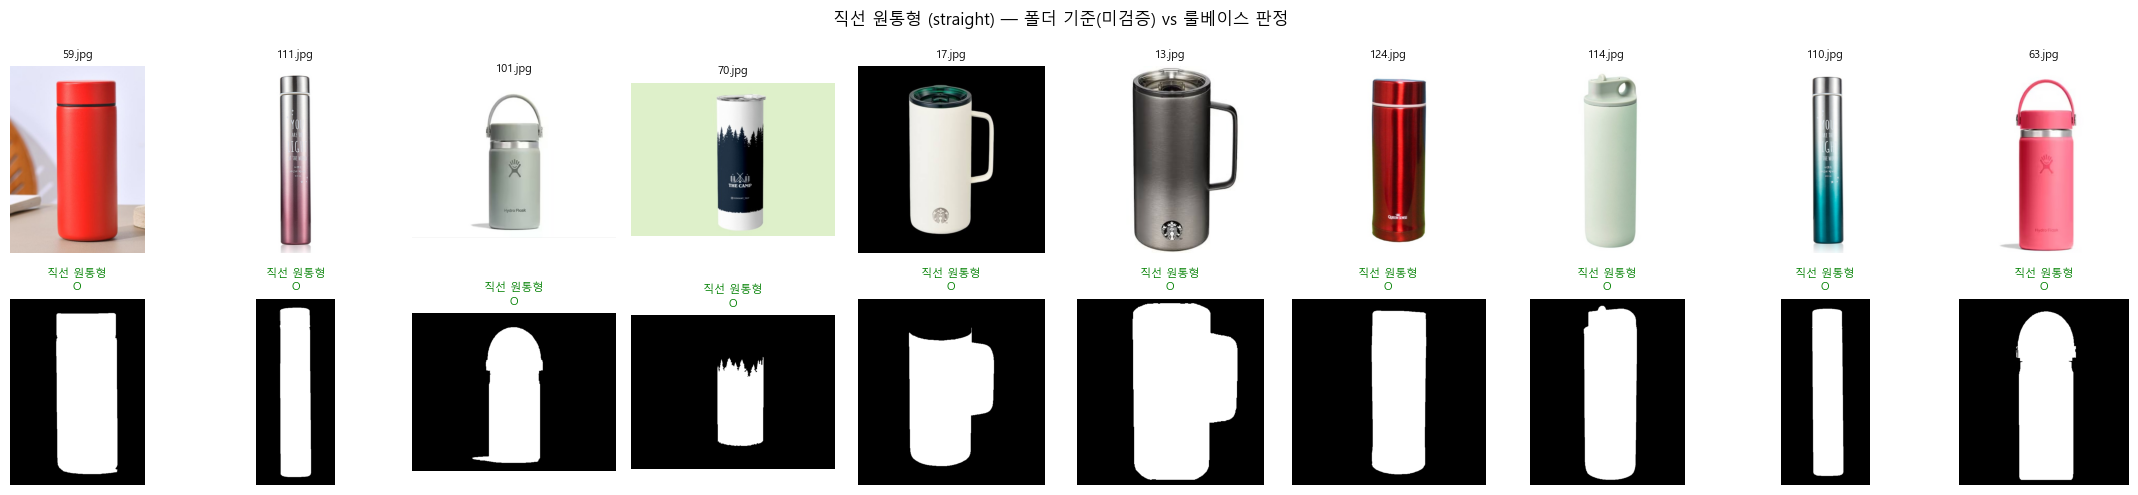

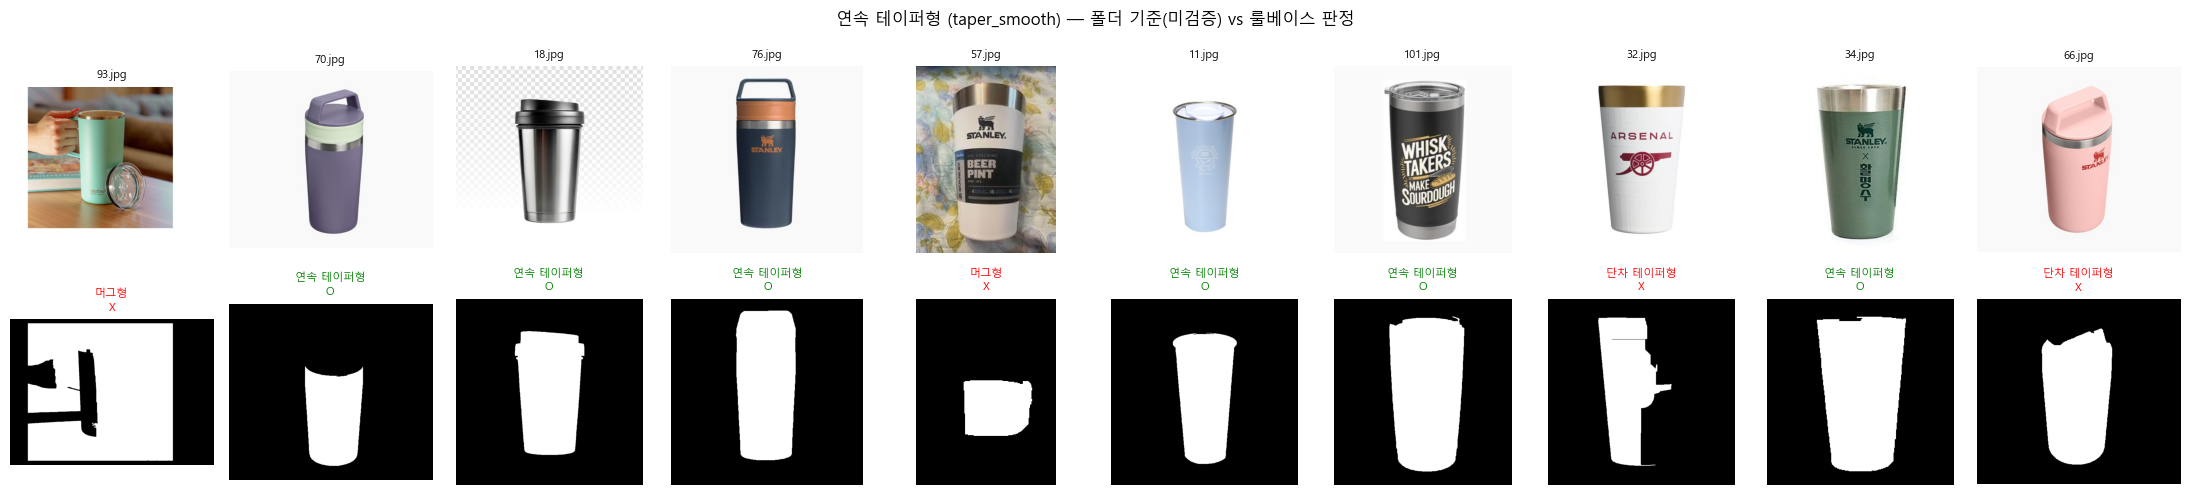

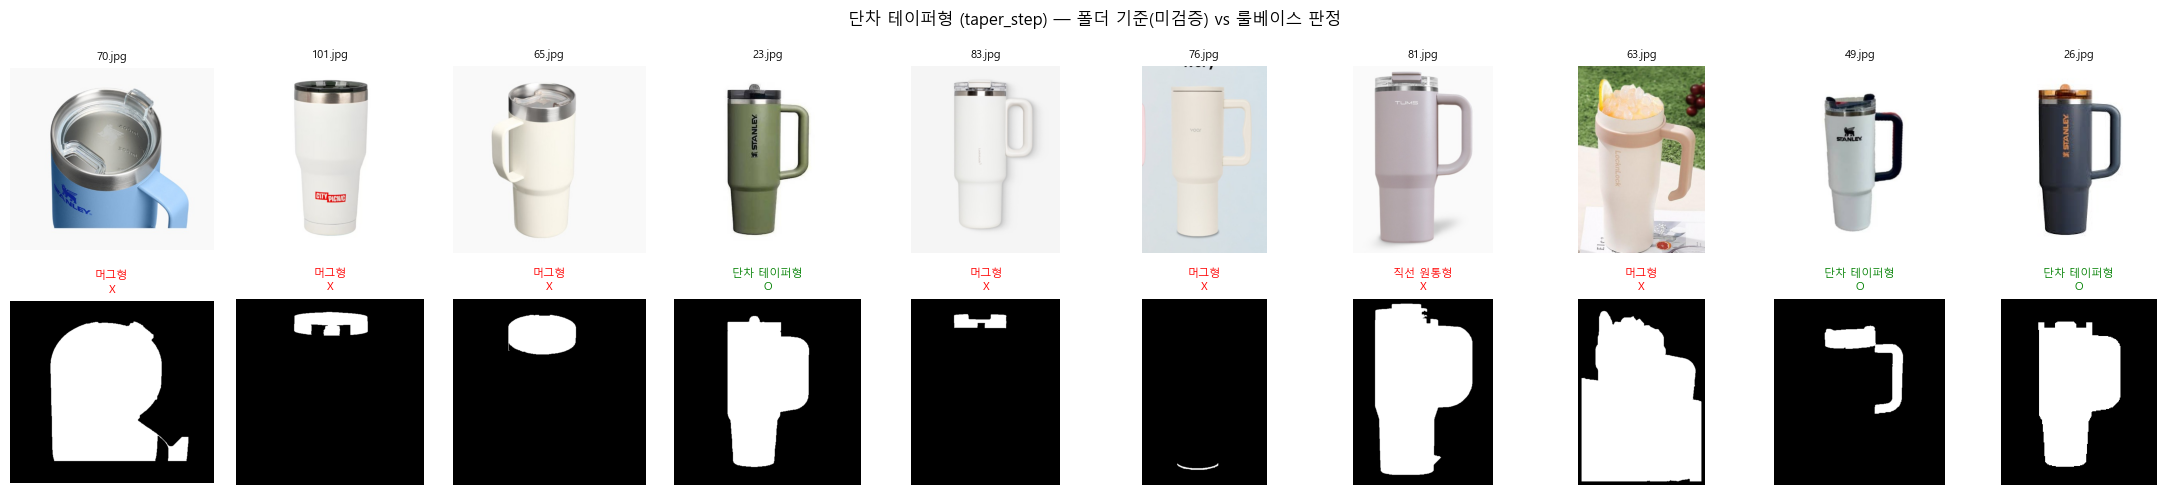

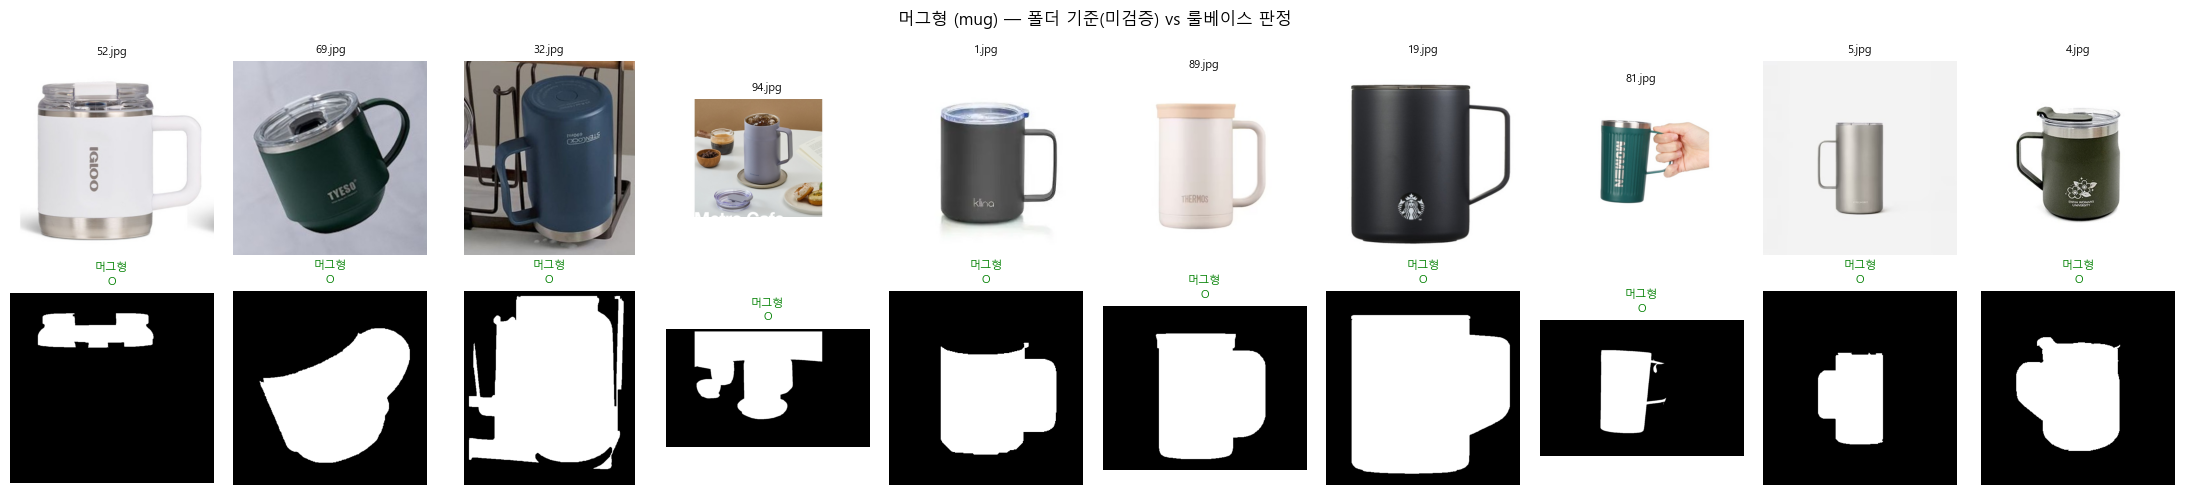

In [3]:
all_results = []

for cls in CLASSES:
    paths = samples[cls]
    n = len(paths)
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5))
    if n == 1:
        axes = axes.reshape(2, 1)

    for i, path in enumerate(paths):
        name = os.path.basename(path)
        image = imread_unicode(path)
        mask = get_mask(image)
        result = classify_shape(mask)
        pred = result["shape"]
        match = pred == cls

        axes[0, i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(name, fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].set_title(
            f"{SHAPE_LABELS_KO[pred]}\n{'O' if match else 'X'}",
            fontsize=8,
            color=("green" if match else "red"),
        )
        axes[1, i].axis("off")

        all_results.append({"folder_class": cls, "file": name, "predicted": pred, "match": match})

    fig.suptitle(f"{SHAPE_LABELS_KO[cls]} ({cls}) — 폴더 기준(미검증) vs 룰베이스 판정", fontsize=12)
    plt.tight_layout()
    plt.show()

## 요약 (폴더 라벨과 룰베이스 판정 일치율 — 참고용, 진짜 accuracy 아님)

In [4]:
header = f"{'클래스':14s} {'표본':>6s} {'일치':>6s} {'일치율':>8s}"
print(header)
print("-" * len(header))
for cls in CLASSES:
    cls_results = [r for r in all_results if r["folder_class"] == cls]
    matched = sum(r["match"] for r in cls_results)
    total = len(cls_results)
    rate = matched / total * 100 if total else 0
    print(f"{cls:14s} {total:6d} {matched:6d} {rate:7.1f}%")

overall_matched = sum(r["match"] for r in all_results)
overall_total = len(all_results)
print("-" * len(header))
rate = overall_matched / overall_total * 100 if overall_total else 0
print(f"{'합계':14s} {overall_total:6d} {overall_matched:6d} {rate:7.1f}%")

클래스                표본     일치      일치율
-------------------------------------
straight           10     10   100.0%
taper_smooth       10      6    60.0%
taper_step         10      3    30.0%
mug                10     10   100.0%
-------------------------------------
합계                 40     29    72.5%


## 폴더 라벨별 실제 판정 분포 (혼동 확인용)

In [5]:
for cls in CLASSES:
    cls_results = [r for r in all_results if r["folder_class"] == cls]
    counts = Counter(r["predicted"] for r in cls_results)
    breakdown = ", ".join(f"{SHAPE_LABELS_KO[k]}({k})={v}" for k, v in counts.most_common())
    print(f"{cls:14s}: {breakdown}")

straight      : 직선 원통형(straight)=10
taper_smooth  : 연속 테이퍼형(taper_smooth)=6, 머그형(mug)=2, 단차 테이퍼형(taper_step)=2
taper_step    : 머그형(mug)=6, 단차 테이퍼형(taper_step)=3, 직선 원통형(straight)=1
mug           : 머그형(mug)=10


**해석 시 주의**: 여기서 나온 "불일치"는 두 가지 원인이 섞여 있다 — (1) 룰베이스 판정 자체의 오류, (2) `data/raw2`에 아직 검수 안 된 엉뚱한 이미지가 섞여 있어서 애초에 폴더 라벨 자체가 틀린 경우. 이 노트북만으로는 둘을 구분할 수 없다 — 실제 판정이 이상하면 원본 이미지를 먼저 눈으로 확인할 것.